# Pira 2.0 Dataset Analysis for Multiple-Choice Question Validation

This notebook explores the Pira 2.0 dataset, which contains questions and answers in both English and Portuguese about the ocean, the Brazilian coast, and climate change. The goal is to understand the data structure, identify potential issues, and prepare it for fine-tuning a multilingual model to validate multiple-choice questions.

Pira 2.0 is an enhanced version of the original Pira dataset with additional features including:
- Automatic translations of supporting texts into Portuguese
- Classification labels for answer triggering
- Multiple-choice QA extension
- Automatically-generated paraphrases for questions and answers

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import Counter

# Set visualization style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

## 1. Data Loading and Initial Exploration

The Pira 2.0 dataset is organized into train, validation, and test splits, making it ready for machine learning applications. Let's load these files and explore their structure.

In [5]:
# Define paths to dataset files
data_path = 'Pira/Data/'

# List available files
print("Files in Pira 2.0 dataset:")
print(os.listdir(data_path))

Files in Pira 2.0 dataset:
['validation.csv', 'test.csv', 'train.csv']


In [6]:
# Load the dataset splits
df_train = pd.read_csv(data_path + 'train.csv')
df_validation = pd.read_csv(data_path + 'validation.csv')
df_test = pd.read_csv(data_path + 'test.csv')

# Display basic information about the dataset splits
print("Train set shape:", df_train.shape)
print("Validation set shape:", df_validation.shape)
print("Test set shape:", df_test.shape)

Train set shape: (1806, 31)
Validation set shape: (225, 22)
Test set shape: (227, 22)


Let's examine the structure of the dataset to understand the available features and content.

In [7]:
# Examine the structure of the training dataset
print("Columns in the training dataset:")
print(df_train.columns.tolist())
print("\nSample data from the training dataset:")
df_train.head()

Columns in the training dataset:
['Unnamed: 0.1', 'Unnamed: 0', 'id_qa', 'corpus', 'question_en_origin', 'question_pt_origin', 'question_en_paraphase', 'question_pt_paraphase', 'answer_en_origin', 'answer_pt_origin', 'answer_en_validate', 'answer_pt_validate', 'abstract', 'eid_article_scopus', 'question_generic', 'answer_in_text', 'answer_difficulty', 'question_meaningful', 'answer_equivalent', 'question_type', 'abstract_translated_pt', 'pt_question_translated_to_en', 'at_labels', 'question_AUT_EN_1', 'question_AUT_EN_2', 'answer_AUT_EN_1', 'answer_AUT_EN_2', 'question_AUT_PT_1', 'question_AUT_PT_2', 'answer_AUT_PT_1', 'answer_AUT_PT_2']

Sample data from the training dataset:


,Unnamed: 0.1,Unnamed: 0,id_qa,corpus,question_en_origin,question_pt_origin,question_en_paraphase,question_pt_paraphase,answer_en_origin,answer_pt_origin,answer_en_validate,answer_pt_validate,abstract,eid_article_scopus,question_generic,answer_in_text,answer_difficulty,question_meaningful,answer_equivalent,question_type,abstract_translated_pt,pt_question_translated_to_en,at_labels,question_AUT_EN_1,question_AUT_EN_2,answer_AUT_EN_1,answer_AUT_EN_2,question_AUT_PT_1,question_AUT_PT_2,answer_AUT_PT_1,answer_AUT_PT_2
0,0,0,A160,1,What method can be used to estimate air–sea se...,Qual método pode ser usado para estimar os flu...,To estimate sensitive air-sea sensible and lat...,Para estimar fluxos ar-mar de calor sensíveis ...,The turbulent covariance method.,O método de covariância turbulenta.,The eddy covariance (EC) method.,O método da covariância turbulenta (EC).,Turbulent air-sea heat fluxes were computed fr...,2-s2.0-85092110011,1.0,1.0,1.0,5.0,5.0,What,Os fluxos de calor do ar turbulento foram calc...,Which method can be used to estimate sensitive...,1.0,How can we estimate air–sea sensible- and late...,How can we estimate air–sea sensible– and late...,The method of covariance.,The method is turbulent.,Qual é o método mais apropriado para estimar a...,Qual método pode ser usado para calcular os fl...,O método de covariância turbulenta.,O método de covariância turbulenta.
1,1,1,B2252,2,Why is mercury considered one of the ten most ...,Porque o mercúrio é considerado uma das dez su...,What's the reason mercury is considered one of...,Por quais motivos o mercurio é considerado uma...,"Because in humans, exposure can be harmful to ...","Pois em humanos, a exposição pode ser prejudic...",Because the principal form of mercury to which...,Porque a principal forma de mercúrio ao qual o...,Human health can be affected by many aspects o...,NaN,0.0,1.0,4.0,4.0,4.0,Why,A saúde humana pode ser afetada por muitos asp...,Why is mercury considered one of the ten most ...,1.0,Mercury is one of the most toxic substances.,Why is mercury considered one of the most toxi...,Exposure to this neurotoxin can be harmful to ...,Exposure to this neurotoxin can be harmful to ...,Porque o mercúrio é considerado uma das dez su...,Por que o mercúrio é considerado uma das dez s...,"Em humanos, a exposição pode causar prejuízos ...","Em humanos, a exposição pode afetar o desenvol..."
2,2,2,B2044,2,What are the biological benefits of marine hyd...,Quais são os benefícios biológicos de hidratos...,NaN,NaN,Marine hydrates with seeping gas are high biod...,Hidratos marinhos com escape de gás são ambien...,Rich level of biodiversity supported by chemos...,Rico nível de biodiversidade sustentado por ba...,Marine hydrates (mainly methane hydrates) exis...,NaN,0.0,1.0,4.0,3.0,4.0,What,Os hidratos marinhos (principalmente hidratos ...,What are the biological benefits of marine hyd...,NaN,What are the benefits of the marine environment?,What are the benefits of marine lysis?,Marine liquefaction is high biodiverse environ...,Marine liquefaction is high biodiverse.,Que são os efeitos biológicos de hidratos mari...,Qual são os benefícios biológicos de hidratos ...,Os mares com escape de gás são ambientes de gr...,Os lagos de escape de gás constituem ambientes...
3,3,3,A931,1,What is the most productive oil province in Br...,Qual é a província petrolífera mais produtiva ...,NaN,NaN,The Campos basin,A bacia de Campos,The Campos basin,A bacia de Campos,"In 1939, the Lobito oil field, Brazil's first,...",2-s2.0-24769642,0.0,1.0,1.0,5.0,5.0,What,"Em 1939, o campo de óleo de Lobito, o primeiro...",What is the most productive oil province in Br...,1.0,What is the most productive oil province in Br...,What is the most productive oil region in Brazil?,The basin is called the Campos.,The basin of the Campos.,Qual é a maior produção petrolífera do Brasil?,Qual é a mais produtiva da América Latina?,A bacia de Campos é formada por rios.,A bacia de Campos fica entre os Campos
4,4,4,B

## 2. Understanding the Enhanced Features of Pira 2.0

Pira 2.0 includes several enhancements over the original dataset. Let's explore these features:

In [8]:
# Check for new features in Pira 2.0
new_features = [
    'abstract', 'abstract_translated_pt', 'pt_question_translated_to_en', 'at_labels',
    'question_AUT_EN_1', 'question_AUT_EN_2', 'answer_AUT_EN_1', 'answer_AUT_EN_2',
    'question_AUT_PT_1', 'question_AUT_PT_2', 'answer_AUT_PT_1', 'answer_AUT_PT_2'
]

print("New features in Pira 2.0:")
for feature in new_features:
    if feature in df_train.columns:
        print(f"- {feature}: Present")
        # Show a non-null example if available
        non_null_example = df_train[~df_train[feature].isna()][feature].iloc[0] if not df_train[feature].isna().all() else "All values are null"
        print(f"  Example: {non_null_example[:100]}..." if isinstance(non_null_example, str) and len(non_null_example) > 100 else f"  Example: {non_null_example}")
    else:
        print(f"- {feature}: Not present")

New features in Pira 2.0:
- abstract: Present
  Example: Turbulent air-sea heat fluxes were computed from in situ high-frequency micrometeorological data dur...
- abstract_translated_pt: Present
  Example: Os fluxos de calor do ar turbulento foram calculados a partir de dados micrometeorológicos de alta f...
- pt_question_translated_to_en: Present
  Example: Which method can be used to estimate sensitive and latent heat airflows?
- at_labels: Present
  Example: 1.0
- question_AUT_EN_1: Present
  Example: How can we estimate air–sea sensible- and latent-heat fluxes?
- question_AUT_EN_2: Present
  Example: How can we estimate air–sea sensible– and latent-heat fluxes?
- answer_AUT_EN_1: Present
  Example: The method of covariance.
- answer_AUT_EN_2: Present
  Example: The method is turbulent.
- question_AUT_PT_1: Present
  Example: Qual é o método mais apropriado para estimar as correntes de ar-ar de calor sensível a latente?
- question_AUT_PT_2: Present
  Example: Qual método pode ser us

## 3. Data Quality and Completeness

Let's check for missing values and assess the overall quality of the dataset.

In [9]:
# Check for missing values in the training dataset
missing_values = df_train.isna().sum()
print("Missing values in the training dataset:")
print(missing_values[missing_values > 0])

Missing values in the training dataset:
question_en_paraphase    222
question_pt_paraphase    222
answer_en_validate        50
answer_pt_validate        50
eid_article_scopus       503
question_generic          51
answer_in_text            51
answer_difficulty         51
question_meaningful       51
answer_equivalent         51
question_type             51
at_labels                229
dtype: int64


## 4. Exploratory Data Analysis

Now let's perform some exploratory analysis to better understand the dataset.

In [10]:
# Examine the distribution of languages
if 'language' in df_train.columns:
    plt.figure(figsize=(10, 6))
    df_train['language'].value_counts().plot(kind='bar')
    plt.title('Distribution of Languages')
    plt.xlabel('Language')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No explicit 'language' column found. The dataset contains both English and Portuguese content.")

No explicit 'language' column found. The dataset contains both English and Portuguese content.


In [11]:
# Extract and examine multiple-choice questions if available
mc_columns = [col for col in df_train.columns if 'choice' in col.lower() or 'option' in col.lower()]
if mc_columns:
    print("Multiple-choice columns found:")
    print(mc_columns)
    # Show a sample multiple-choice question
    sample_row = df_train.loc[~df_train[mc_columns].isna().all(axis=1)].iloc[0]
    print("\nSample multiple-choice question:")
    print(f"Question: {sample_row['question_en_origin']}")
    for col in mc_columns:
        print(f"{col}: {sample_row[col]}")
else:
    print("No explicit multiple-choice columns found in this dataset split.")
    print("The multiple-choice extension might be in a separate file or structure.")

No explicit multiple-choice columns found in this dataset split.
The multiple-choice extension might be in a separate file or structure.


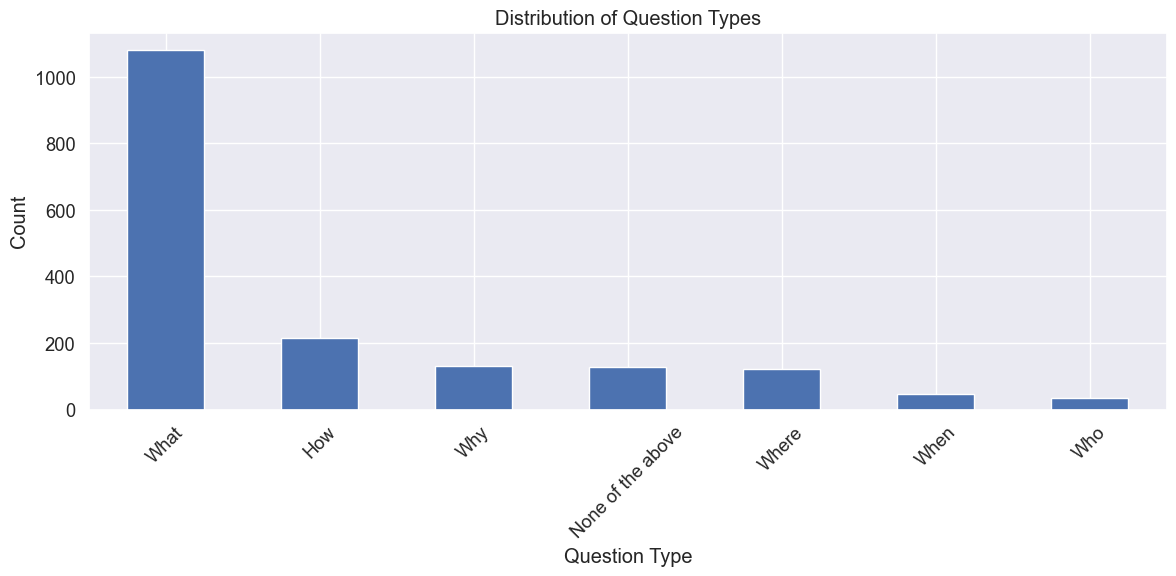

Question type distribution:
What: 1079 (59.75%)
How: 214 (11.85%)
Why: 131 (7.25%)
None of the above: 127 (7.03%)
Where: 122 (6.76%)
When: 48 (2.66%)
Who: 34 (1.88%)


In [12]:
# Analyze the distribution of question types
if 'question_type' in df_train.columns:
    plt.figure(figsize=(12, 6))
    question_type_counts = df_train['question_type'].value_counts()
    question_type_counts.plot(kind='bar')
    plt.title('Distribution of Question Types')
    plt.xlabel('Question Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Question type distribution:")
    for q_type, count in question_type_counts.items():
        percentage = (count / len(df_train)) * 100
        print(f"{q_type}: {count} ({percentage:.2f}%)")

In [13]:
# Check for class imbalance in languages
print("Distribution of questions by corpus:")
corpus_counts = df_train['corpus'].value_counts()
for corpus, count in corpus_counts.items():
    percentage = (count / len(df_train)) * 100
    print(f"Corpus {corpus}: {count} ({percentage:.2f}%)")

Distribution of questions by corpus:
Corpus 1: 1314 (72.76%)
Corpus 2: 492 (27.24%)


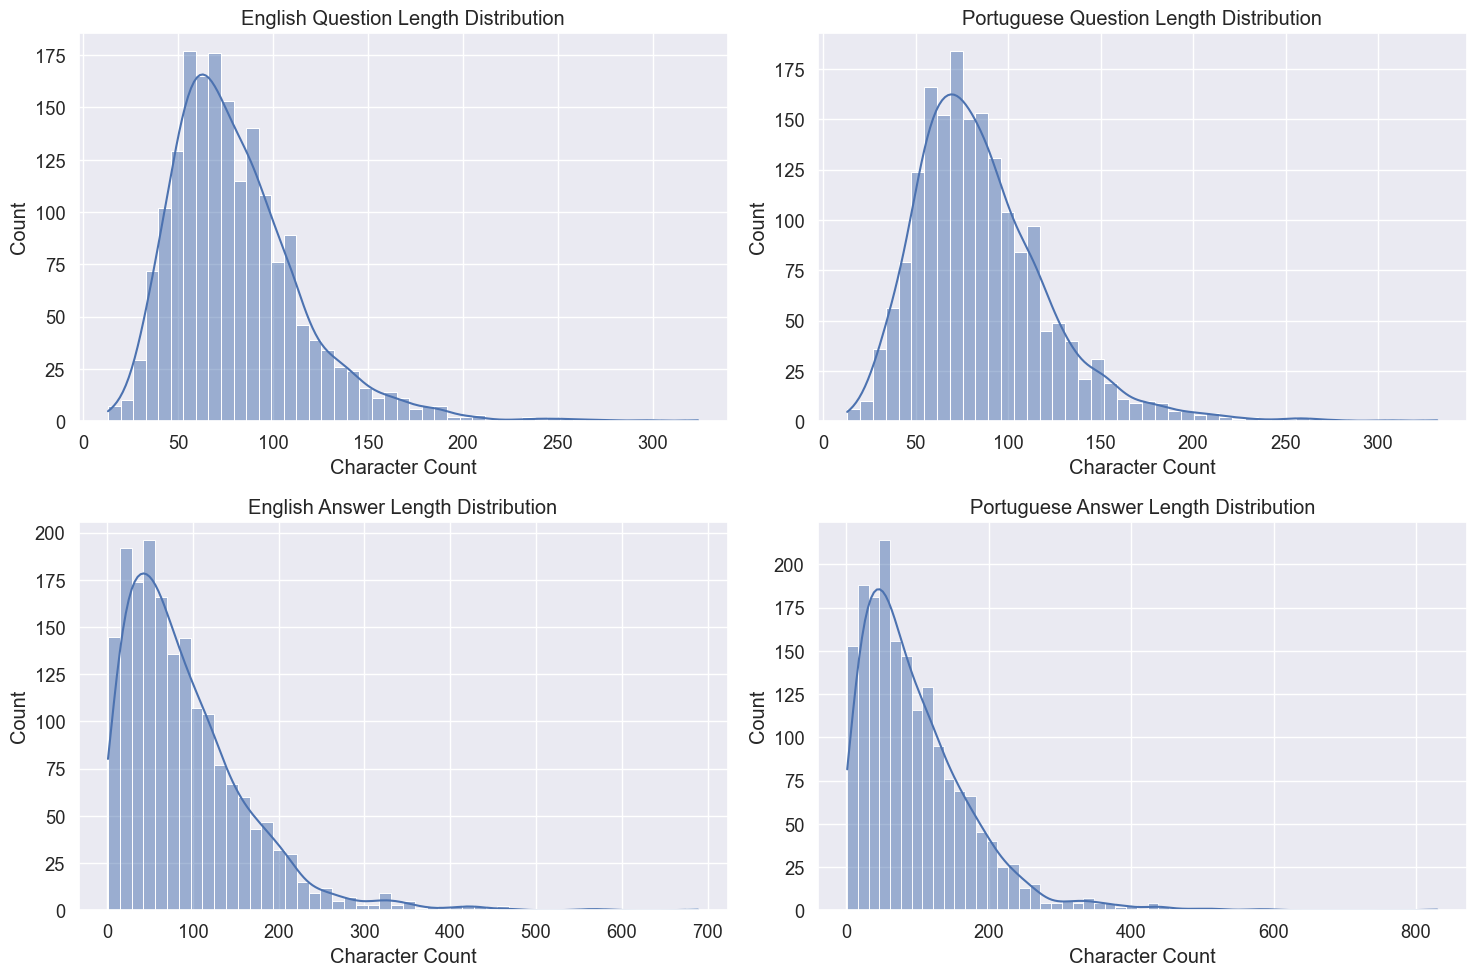

Text length statistics:
       question_en_length  question_pt_length  answer_en_length  answer_pt_length
count         1806.000000         1806.000000       1806.000000       1806.000000
mean            80.646179           85.660022         90.334994         96.508859
std             34.902372           36.339102         73.599336         79.198567
min             13.000000           13.000000          1.000000          1.000000
25%             56.000000           61.000000         38.000000         41.000000
50%             74.000000           79.000000         72.500000         78.000000
75%             97.000000          104.000000        123.000000        133.000000
max            324.000000          332.000000        689.000000        830.000000


In [14]:
# Check for text length distribution in questions and passages
df_train['question_en_length'] = df_train['question_en_origin'].str.len()
df_train['question_pt_length'] = df_train['question_pt_origin'].str.len()
df_train['answer_en_length'] = df_train['answer_en_origin'].str.len()
df_train['answer_pt_length'] = df_train['answer_pt_origin'].str.len()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_train['question_en_length'], kde=True)
plt.title('English Question Length Distribution')
plt.xlabel('Character Count')

plt.subplot(2, 2, 2)
sns.histplot(df_train['question_pt_length'], kde=True)
plt.title('Portuguese Question Length Distribution')
plt.xlabel('Character Count')

plt.subplot(2, 2, 3)
sns.histplot(df_train['answer_en_length'], kde=True)
plt.title('English Answer Length Distribution')
plt.xlabel('Character Count')

plt.subplot(2, 2, 4)
sns.histplot(df_train['answer_pt_length'], kde=True)
plt.title('Portuguese Answer Length Distribution')
plt.xlabel('Character Count')

plt.tight_layout()
plt.show()

print("Text length statistics:")
print(df_train[['question_en_length', 'question_pt_length', 'answer_en_length', 'answer_pt_length']].describe())

Answer triggering labels distribution:
1.0: 1432 (79.29%)
0.0: 145 (8.03%)


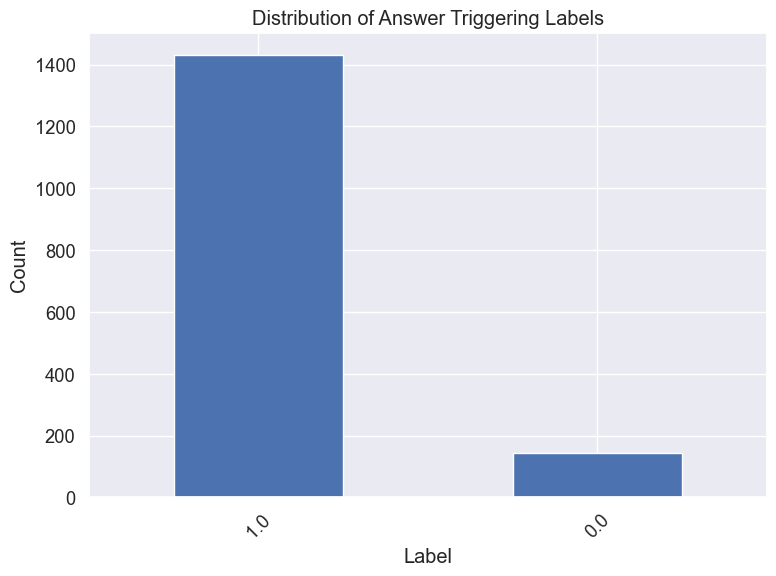

In [15]:
# Check for completeness of multiple-choice questions
if 'at_labels' in df_train.columns:
    print("Answer triggering labels distribution:")
    at_label_counts = df_train['at_labels'].value_counts()
    for label, count in at_label_counts.items():
        percentage = (count / len(df_train)) * 100
        print(f"{label}: {count} ({percentage:.2f}%)")
        
    plt.figure(figsize=(8, 6))
    at_label_counts.plot(kind='bar')
    plt.title('Distribution of Answer Triggering Labels')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
# Separate the data by language for further analysis
# Since we have both English and Portuguese versions of questions and answers
# We can create separate dataframes for analysis in each language

# Create English dataset
df_en = df_train.copy()
df_en['question'] = df_en['question_en_origin']
df_en['answer'] = df_en['answer_en_origin']
df_en['language'] = 'English'

# Create Portuguese dataset
df_pt = df_train.copy()
df_pt['question'] = df_pt['question_pt_origin']
df_pt['answer'] = df_pt['answer_pt_origin']
df_pt['language'] = 'Portuguese'

# Combine for comparison
df_combined = pd.concat([df_en, df_pt])

print(f"Combined dataset shape: {df_combined.shape}")
print(f"English questions: {len(df_en)}")
print(f"Portuguese questions: {len(df_pt)}")

Combined dataset shape: (3612, 38)
English questions: 1806
Portuguese questions: 1806


## 5. Examining Automatic Translations and Paraphrases

One of the key enhancements in Pira 2.0 is the inclusion of automatic translations and paraphrases. Let's examine these features.

In [17]:
# Examine automatic translations and paraphrases
auto_translation_cols = [
    'pt_question_translated_to_en',
    'question_AUT_EN_1', 'question_AUT_EN_2',
    'answer_AUT_EN_1', 'answer_AUT_EN_2',
    'question_AUT_PT_1', 'question_AUT_PT_2',
    'answer_AUT_PT_1', 'answer_AUT_PT_2'
]

# Select a sample row with non-null values in these columns
sample_row = None
for _, row in df_train.iterrows():
    if not row[auto_translation_cols].isna().all():
        sample_row = row
        break

if sample_row is not None:
    print("Sample question with automatic translations and paraphrases:")
    print(f"Original English Question: {sample_row['question_en_origin']}")
    print(f"Original Portuguese Question: {sample_row['question_pt_origin']}")
    print("\nAutomatic Translations and Paraphrases:")
    for col in auto_translation_cols:
        if not pd.isna(sample_row[col]):
            print(f"{col}: {sample_row[col]}")
else:
    print("No rows found with automatic translation or paraphrase data.")

Sample question with automatic translations and paraphrases:
Original English Question: What method can be used to estimate air–sea sensible- and latent-heat fluxes?
Original Portuguese Question: Qual método pode ser usado para estimar os fluxos ar-mar de calor sensível e latente?

Automatic Translations and Paraphrases:
pt_question_translated_to_en: Which method can be used to estimate sensitive and latent heat airflows?
question_AUT_EN_1: How can we estimate air–sea sensible- and latent-heat fluxes?
question_AUT_EN_2: How can we estimate air–sea sensible– and latent-heat fluxes?
answer_AUT_EN_1: The method of covariance.
answer_AUT_EN_2: The method is turbulent.
question_AUT_PT_1: Qual é o método mais apropriado para estimar as correntes de ar-ar de calor sensível a latente?
question_AUT_PT_2: Qual método pode ser usado para calcular os fluxos ar-mar com intensidades sensível e latente?
answer_AUT_PT_1: O método de covariância turbulenta.
answer_AUT_PT_2: O método de covariância turb

## 6. Examining the Answer Triggering Feature

Pira 2.0 includes answer triggering labels, which indicate whether a question can be answered or not. Let's explore this feature.

In [18]:
# Examine answer triggering feature
if 'at_labels' in df_train.columns:
    # Get examples of answerable and unanswerable questions
    answerable = df_train[df_train['at_labels'] == 1].head(3)
    unanswerable = df_train[df_train['at_labels'] == 0].head(3) if 0 in df_train['at_labels'].values else None
    
    print("Examples of answerable questions:")
    for i, row in answerable.iterrows():
        print(f"Question: {row['question_en_origin']}")
        print(f"Answer: {row['answer_en_origin']}")
        print()
    
    if unanswerable is not None and not unanswerable.empty:
        print("\nExamples of unanswerable questions:")
        for i, row in unanswerable.iterrows():
            print(f"Question: {row['question_en_origin']}")
            print()
    else:
        print("\nNo examples of unanswerable questions found in the sample.")
else:
    print("Answer triggering labels not found in this dataset.")

Examples of answerable questions:
Question: What method can be used to estimate air–sea sensible- and latent-heat fluxes?
Answer: The turbulent covariance method.

Question: Why is mercury considered one of the ten most toxic substances to human health?
Answer: Because in humans, exposure can be harmful to fetal brain development. Research has demonstrated a link between exposure to this neurotoxin and developmental deficits the fine motor skills, language and memory of the fetus.

Question: What is the most productive oil province in Brazil?
Answer: The Campos basin


Examples of unanswerable questions:
Question: What is the content os the study case presented in this paper?

Question: What is the main characteristic of countries where tourism is the main source of employment?

Question: What was the number of accidents involving Petrobras support vessels in 2012?



## 7. Conclusion and Next Steps

Based on our analysis of the Pira 2.0 dataset, we can draw the following conclusions:

1. The dataset is well-structured and organized into train, validation, and test splits.
2. It contains questions and answers in both English and Portuguese.
3. The dataset includes enhanced features such as automatic translations, paraphrases, and answer triggering labels.
4. [Additional conclusions will be added based on the analysis results]

Next steps for utilizing this dataset could include:

1. Fine-tuning a multilingual model for multiple-choice question validation.
2. Developing a model for answer triggering using the provided labels.
3. Exploring cross-lingual transfer learning between English and Portuguese.
4. Analyzing the quality of automatic translations and paraphrases.
5. [Additional next steps will be added based on the analysis results]